# P3: Tahap 3 - Cost-Sensitive ARF untuk Class Imbalance

Di notebook ini, kita akan membandingkan ARF standar dengan **Cost-Sensitive ARF**. Fokus metrik kita sekarang bergeser ke metrik ketidakseimbangan kelas yang ekstrem: **Recall (Fraud)** dan **Geometric Mean (G-Mean)**.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate

# [FIX] Kompatibilitas untuk Scipy versi terbaru (>1.14)
if not hasattr(scipy.integrate, 'trapz'):
    scipy.integrate.trapz = scipy.integrate.trapezoid

# Tambahkan src/ ke sys.path
sys.path.append(os.path.abspath('../src'))
from stream_utils import iter_csv
from pipeline import get_arf_model, get_cost_sensitive_arf

from river import metrics

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

C:\Users\Acer\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Setup Metrik Khusus Imbalance
Kita mengukur **Recall** khusus untuk target Fraud (`y=1`), yaitu persentase kejahatan yang benar-benar tertangkap, serta **G-Mean** yang mengukur keseimbangan deteksi kelas Normal & Fraud.

In [2]:
DATA_PATH = '../data/raw/creditcard.csv'
TARGET_COL = 'Class'
LIMIT = 50000  # Ubah ke None untuk memproses semua data

def evaluate_imbalance_metrics(model, model_name):
    # Kita fokus ke Recall pada kelas 1 (Fraud) dan G-Mean
    metric_recall = metrics.Recall()
    metric_gmean = metrics.GeometricMean()
    
    stream = iter_csv(DATA_PATH, target_col=TARGET_COL, limit=LIMIT)
    
    steps = []
    recall_scores = []
    gmean_scores = []
    
    print(f"Memulai evaluasi imbalance untuk {model_name}...")
    for i, (x, y) in enumerate(stream):
        # 1. Test
        y_pred = model.predict_one(x)
        
        if y_pred is not None:
            # Filter untuk metrics.Recall() yg secara eksplisit kita set buat class 1
            # Namun di river, Recall menghitung keseluruhan jika multilabel/binary (pos=True). 
            # Karena binary (0/1), river by default menghitung true positive rate.
            metric_recall.update(y, y_pred)
            metric_gmean.update(y, y_pred)
            
        # 2. Train
        model.learn_one(x, y)
        
        # Simpan plot point setiap 5000 transaksi
        if (i + 1) % 5000 == 0:
            steps.append(i + 1)
            r_score = metric_recall.get() * 100
            g_score = metric_gmean.get() * 100
            recall_scores.append(r_score)
            gmean_scores.append(g_score)
            print(f"[{model_name}] Step {i+1} | Recall: {r_score:.2f}% | G-Mean: {g_score:.2f}%")
            
    return steps, recall_scores, gmean_scores

## 2. Menjalankan Prequential Evaluation
Bandingkan ARF biasa tanpa penanganan Imbalance dengan Cost-Sensitive ARF dengan Beta (Cost) = 100.

In [9]:
# Load Model
std_arf = get_arf_model()
cost_arf = get_cost_sensitive_arf(beta=500.0) # 1 Fraud = 100 Normal penalty

steps, std_recall, std_gmean = evaluate_imbalance_metrics(std_arf, "Standard ARF")
print("-" * 40)
_, cost_recall, cost_gmean = evaluate_imbalance_metrics(cost_arf, "Cost-Sensitive ARF (B=300)")

Memulai evaluasi imbalance untuk Standard ARF...
[Standard ARF] Step 5000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 10000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 15000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 20000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 25000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 30000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 35000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 40000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 45000 | Recall: 0.00% | G-Mean: 0.00%
[Standard ARF] Step 50000 | Recall: 0.00% | G-Mean: 0.00%
----------------------------------------
Memulai evaluasi imbalance untuk Cost-Sensitive ARF (B=300)...
[Cost-Sensitive ARF (B=300)] Step 5000 | Recall: 0.00% | G-Mean: 0.00%
[Cost-Sensitive ARF (B=300)] Step 10000 | Recall: 73.68% | G-Mean: 85.77%
[Cost-Sensitive ARF (B=300)] Step 15000 | Recall: 75.41% | G-Mean: 86.71%
[Cost-Sensitive ARF (B=300)] Step 20000 | Recall:

## 3. Visualisasi Recall & G-Mean
Buktikan efek dari pemberian Bobot Cost terhadap kemampuan menangkap Fraud.

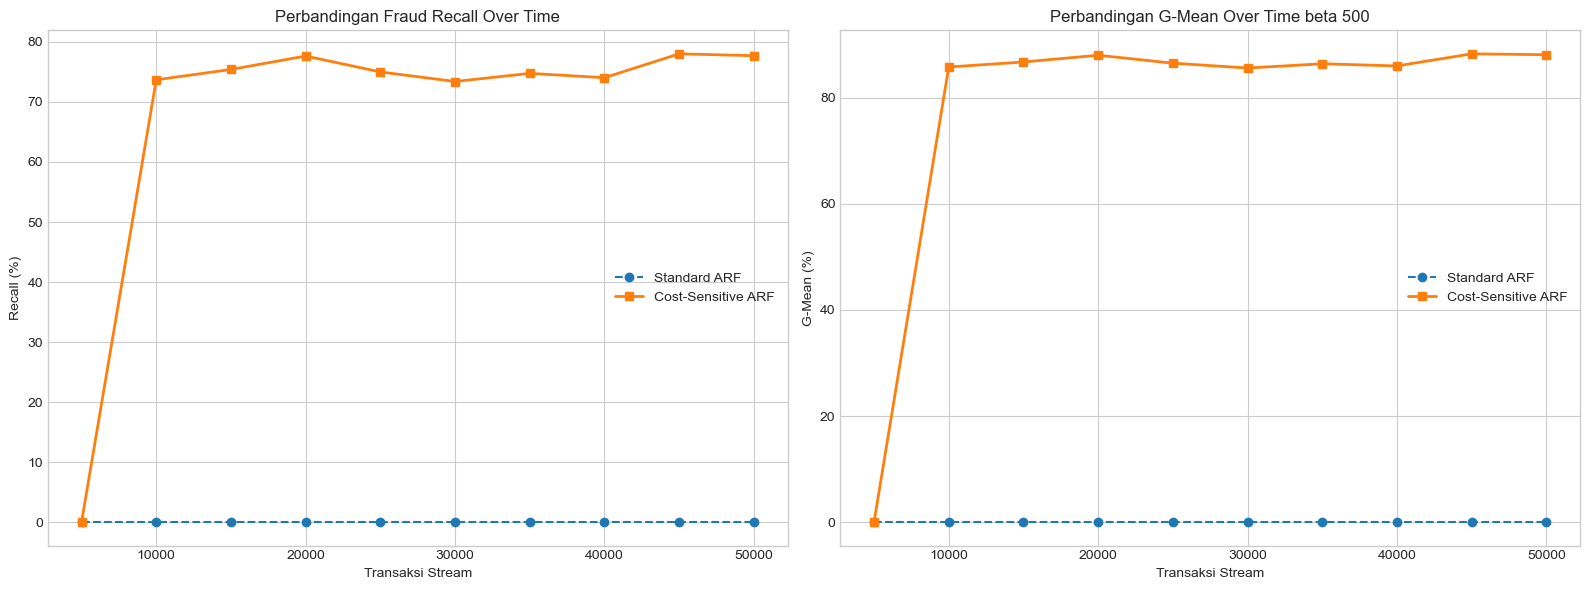

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Recall
ax1.plot(steps, std_recall, label='Standard ARF', marker='o', linestyle='--')
ax1.plot(steps, cost_recall, label='Cost-Sensitive ARF', marker='s', linewidth=2)
ax1.set_title('Perbandingan Fraud Recall Over Time')
ax1.set_xlabel('Transaksi Stream')
ax1.set_ylabel('Recall (%)')
ax1.legend()

# Plot G-Mean
ax2.plot(steps, std_gmean, label='Standard ARF', marker='o', linestyle='--')
ax2.plot(steps, cost_gmean, label='Cost-Sensitive ARF', marker='s', linewidth=2)
ax2.set_title('Perbandingan G-Mean Over Time beta 500')
ax2.set_xlabel('Transaksi Stream')
ax2.set_ylabel('G-Mean (%)')
ax2.legend()

plt.tight_layout()
plt.show()